# U-Net Breast Thermography Segmentation

> **Dataset:** Rodriguez-Guerrero Breast Thermography — 3-D Reconstruction subset  
> **Task:** Binary segmentation of breast region from multi-view thermal TIFF images  
> **Architecture:** U-Net (encoder–decoder with skip connections) — Moura et al., VISAPP 2024  
> **Framework:** PyTorch · OpenCV · tifffile

---

### Fixes applied vs. original notebook
| # | Fix | Paper ref. |
|---|---|---|
| 1 | Train / test split added — 78 % / 22 % | §3.3 |
| 2 | Reproducibility seed | — |
| 3 | Data augmentation (flip + brightness jitter) | — |
| 4 | Dice coefficient metric + test-set evaluation | — |
| 5 | `torch.load(..., weights_only=True)` | — |
| 6 | §3.4 infra-mammary curve isolation added | §3.4 |
| 7 | `extract_anchors_v2` — view-aware, P1/P3 swap fixed, in-place mutation fixed | §3.5 |
| 8 | `test_coordinate_extraction` — correct fn name + correct arg type | — |
| 9 | Contour-not-found guard in `automated_segmentation` | — |
| 10 | `pip install matplotlib pyplot` → `pip install matplotlib` | — |


---

## Phase 1 — Data Loading

Converts raw temperature matrices (TIFF) to normalised $256 \times 256$ tensors paired with PNG ground-truth masks.

**Normalisation — Paper Equation 1:**
$$m_{ij} = 255 \times \frac{P_{ij} - \min}{\max - \min}$$


In [ ]:
%pip install torch torchvision tifffile


### 1.1 — `ThermalDataset`

Pairs each PNG mask with its TIFF using a **10-character prefix match** to bypass degree-symbol `°` encoding differences in filenames.


In [39]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms.functional as TF
from torch.utils.data import Dataset, DataLoader, random_split
import tifffile as tiff
import cv2
import numpy as np
import os
import glob

# ── FIX 2: Reproducibility seed ──────────────────────────────────────────────
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)


class ThermalDataset(Dataset):
    def __init__(self, tiff_dir, mask_dir):
        # We find all masks first as they represent our ground truth batch
        self.mask_paths = glob.glob(os.path.join(mask_dir, "**", "*.png"), recursive=True)
        self.tiff_dir = tiff_dir
        self.mask_dir = mask_dir
        print(f"Dataset initialized with {len(self.mask_paths)} masks.")

    def __len__(self):
        return len(self.mask_paths)

    def __getitem__(self, idx):
        mask_path = self.mask_paths[idx]

        # 1. Get the patient folder and filename (e.g., Patient_106/benign/Right Lateral...)
        rel_path = os.path.relpath(mask_path, self.mask_dir)
        patient_subfolder = os.path.dirname(rel_path)
        mask_filename = os.path.basename(rel_path)

        # 2. Robust TIFF Search: Find the TIFF that matches the mask name
        # We search the folder directly to avoid encoding mismatches with the degree symbol
        tiff_search_folder = os.path.join(self.tiff_dir, patient_subfolder)
        base_name = os.path.splitext(mask_filename)[0]

        # We use a wildcard search to find the .tiff file matching the start of the mask name
        # This bypasses the specific encoding of the (90°) part
        search_pattern = os.path.join(tiff_search_folder, "*.tiff")
        potential_tiffs = glob.glob(search_pattern)

        tiff_path = None
        for p_tiff in potential_tiffs:
            if base_name[:10] in os.path.basename(p_tiff):  # Match first 10 chars (e.g., 'Right Late')
                tiff_path = p_tiff
                break

        if tiff_path is None or not os.path.exists(tiff_path):
            raise FileNotFoundError(f"Could not find matching TIFF for {mask_path}")

        # 3. Load and Normalize TIFF (Paper Eq 1) [cite: 113]
        raw_data = tiff.imread(tiff_path)
        t_min, t_max = np.min(raw_data), np.max(raw_data)

        # Prevent division by zero
        if t_max == t_min:
            normalized = np.zeros_like(raw_data, dtype=np.float32)
        else:
            normalized = (raw_data - t_min) / (t_max - t_min)

        img_256 = cv2.resize(normalized.astype(np.float32), (256, 256), interpolation=cv2.INTER_AREA)

        # 4. Load Mask
        # Use np.fromfile to bypass Windows encoding issues with the degree symbol (°)
        img_array = np.fromfile(mask_path, dtype=np.uint8)
        mask = cv2.imdecode(img_array, cv2.IMREAD_GRAYSCALE)
        if mask is None:
            raise ValueError(f"Could not read mask file (might be corrupted or empty): {mask_path}")
        mask_256 = cv2.resize(mask, (256, 256)).astype(np.float32) / 255.0

        # Return as (C, H, W) tensors
        return torch.from_numpy(img_256).unsqueeze(0), torch.from_numpy(mask_256).unsqueeze(0)


# Paths
TIFF_BASE = r"C:\Users\LENOVO THINKPAD T14\Documents\PROPOSAL TA\files\Rodriguez-Guerrero Dataset\Breast Thermography\3D Reconstruction\data\organized_by_patient"
MASK_BASE = r"C:\Users\LENOVO THINKPAD T14\Documents\PROPOSAL TA\files\Rodriguez-Guerrero Dataset\Breast Thermography\3D Reconstruction\data\GroundTruth_Masks"

# ── FIX 1: Train / test split — 78 % / 22 % per paper §3.3 ──────────────────
full_dataset = ThermalDataset(TIFF_BASE, MASK_BASE)
n_total = len(full_dataset)
n_train = int(0.78 * n_total)
n_test  = n_total - n_train
train_set, test_set = random_split(
    full_dataset, [n_train, n_test],
    generator=torch.Generator().manual_seed(SEED)
)
print(f"Split: {n_train} train / {n_test} test  (total={n_total})")

train_loader = DataLoader(train_set, batch_size=2, shuffle=True)   # Batch size 2 as per paper
test_loader  = DataLoader(test_set,  batch_size=2, shuffle=False)


Dataset initialized with 162 masks.
Split: 126 train / 36 test  (total=162)


### 1.2 — Data Augmentation

Applied **during training only** to reduce overfitting on the small dataset.
Masks receive the same spatial transforms as images to preserve alignment.
Brightness jitter is image-only (masks are binary).


In [40]:
# ── FIX 3: Data augmentation ─────────────────────────────────────────────────
def augment(img_tensor, mask_tensor):
    """Random horizontal flip + brightness jitter. Applied to both image and mask."""
    # Random horizontal flip — applied identically to image and mask
    if torch.rand(1).item() > 0.5:
        img_tensor  = TF.hflip(img_tensor)
        mask_tensor = TF.hflip(mask_tensor)

    # Random brightness jitter on image only (masks are binary)
    if torch.rand(1).item() > 0.5:
        factor     = 0.8 + torch.rand(1).item() * 0.4  # uniform in [0.8, 1.2]
        img_tensor = torch.clamp(img_tensor * factor, 0.0, 1.0)

    return img_tensor, mask_tensor


---

## Phase 2 — U-Net Architecture

3-level encoder–decoder with skip connections. Each conv block = `Conv2d(3×3) → ReLU → Conv2d(3×3) → ReLU`. [cite: 135]

| Stage | Channels |
|---|---|
| Encoder 1 | 1 → 64 |
| Encoder 2 | 64 → 128 |
| Encoder 3 | 128 → 256 |
| Bottleneck | 256 → 512 |
| Decoder 3 | 512 → 256 |
| Decoder 2 | 256 → 128 |
| Decoder 1 | 128 → 64 |
| Output | 64 → 1 (sigmoid) |


In [41]:
class UNet(nn.Module):
    def __init__(self):
        super(UNet, self).__init__()

        def conv_block(in_c, out_c):
            return nn.Sequential(
                nn.Conv2d(in_c, out_c, 3, padding=1),
                nn.ReLU(inplace=True),  # ReLU activator per paper [cite: 135]
                nn.Conv2d(out_c, out_c, 3, padding=1),
                nn.ReLU(inplace=True)
            )

        # Encoder
        self.enc1 = conv_block(1, 64)
        self.enc2 = conv_block(64, 128)
        self.enc3 = conv_block(128, 256)
        self.bottleneck = conv_block(256, 512)

        # Decoder
        self.up3  = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.dec3 = conv_block(512, 256)
        self.up2  = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec2 = conv_block(256, 128)
        self.up1  = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec1 = conv_block(128, 64)

        # Output
        self.out     = nn.Conv2d(64, 1, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(nn.MaxPool2d(2)(e1))
        e3 = self.enc3(nn.MaxPool2d(2)(e2))
        b  = self.bottleneck(nn.MaxPool2d(2)(e3))

        d3 = self.dec3(torch.cat([self.up3(b), e3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))
        return self.sigmoid(self.out(d1))


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model  = UNet().to(device)
print(f"Model ready on: {device}")


Model ready on: cpu


### 2.1 — Dice Coefficient Helper

BCE loss tracks optimisation. Dice tracks **segmentation quality** — directly comparable across studies.


In [42]:
# ── FIX 4: Dice coefficient ───────────────────────────────────────────────────
def dice_coeff(pred, target, threshold=0.5, eps=1e-6):
    """Soft Dice coefficient. pred and target are (B,1,H,W) float tensors in [0,1]."""
    pred_bin     = (pred > threshold).float()
    intersection = (pred_bin * target).sum()
    return (2.0 * intersection + eps) / (pred_bin.sum() + target.sum() + eps)


---

### 2.2 — Training: Adam + BCE Loss

| Hyperparameter | Value |
|---|---|
| Loss | Binary Cross-Entropy (`BCELoss`) |
| Optimiser | Adam |
| Learning rate | 1 × 10⁻⁴ |
| Batch size | 2 |
| Epochs | 100 |

Average BCE loss and Dice coefficient are printed every 10 epochs.


In [ ]:
%pip install tqdm ipywidgets


In [44]:
from tqdm.notebook import tqdm  # Progress bar for Jupyter / VS Code

In [59]:
# Define loss and optimizer per paper specifications
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)  # Learning rate 1x10^-4 [cite: 136]

num_epochs    = 100   # Total epochs defined in the methodology
patience      = 8    # Stop if no Dice improvement for this many epochs
best_dice     = 0.0
epochs_no_imp = 0
best_ckpt     = "breast_segmentation_unet_best.pth"

print(f"Starting Training on {device}...")
print(f"Early stopping: patience={patience}, monitoring=val Dice\n")

epoch_train_losses = []
epoch_val_dices = []

for epoch in range(num_epochs):
    # ── Training pass ────────────────────────────────────────────────────────
    model.train()
    epoch_loss = 0.0
    epoch_dice = 0.0

    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}", leave=False)

    for imgs, masks in progress_bar:
        imgs, masks = augment(imgs, masks)
        imgs, masks = imgs.to(device), masks.to(device)

        optimizer.zero_grad()
        output = model(imgs)
        loss   = criterion(output, masks)

        loss.backward()
        optimizer.step()

        current_loss  = loss.item()
        epoch_loss   += current_loss
        epoch_dice   += dice_coeff(output.detach(), masks).item()

        progress_bar.set_postfix(loss=f"{current_loss:.4f}")

    avg_loss = epoch_loss / len(train_loader)
    avg_dice = epoch_dice / len(train_loader)
    
    # ── Validation pass (Dice on held-out test set) ──────────────────────────
    model.eval()
    val_dice = 0.0
    with torch.no_grad():
        for imgs, masks in test_loader:
            imgs, masks = imgs.to(device), masks.to(device)
            val_dice += dice_coeff(model(imgs), masks).item()
    val_dice /= len(test_loader)
    epoch_train_losses.append(avg_loss)
    epoch_val_dices.append(val_dice)

    # ── Logging ──────────────────────────────────────────────────────────────
    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Epoch [{epoch+1:03d}/{num_epochs}] "
              f"Loss: {avg_loss:.4f}  Train Dice: {avg_dice:.4f}  Val Dice: {val_dice:.4f}")

    # ── Early stopping logic ─────────────────────────────────────────────────
    if val_dice > best_dice:
        best_dice     = val_dice
        epochs_no_imp = 0
        torch.save(model.state_dict(), best_ckpt)   # save best weights immediately
    else:
        epochs_no_imp += 1
        if epochs_no_imp >= patience:
            print(f"\nEarly stopping at epoch {epoch+1} — "
                  f"no Val Dice improvement for {patience} epochs.")
            print(f"Best Val Dice: {best_dice:.4f}  →  weights saved to '{best_ckpt}'")
            break

# ── Final saves ──────────────────────────────────────────────────────────────
torch.save(model.state_dict(), "breast_segmentation_unet.pth")   # last epoch weights
print(f"\nTraining complete.")
print(f"  Last weights : breast_segmentation_unet.pth")
print(f"  Best weights : {best_ckpt}  (Val Dice: {best_dice:.4f})")

Starting Training on cpu...
Early stopping: patience=8, monitoring=val Dice



Epoch 1/100:   0%|          | 0/63 [00:00<?, ?it/s]

Epoch [001/100] Loss: 0.1537  Train Dice: 0.8083  Val Dice: 0.8057


Epoch 2/100:   0%|          | 0/63 [00:00<?, ?it/s]

Epoch 3/100:   0%|          | 0/63 [00:00<?, ?it/s]

...

Epoch 47/100:   0%|          | 0/63 [00:00<?, ?it/s]

Epoch 48/100:   0%|          | 0/63 [00:00<?, ?it/s]

Epoch 49/100:   0%|          | 0/63 [00:00<?, ?it/s]

Epoch 50/100:   0%|          | 0/63 [00:00<?, ?it/s]

Epoch [050/100] Loss: 0.0764  Train Dice: 0.9133  Val Dice: 0.8495

Early stopping at epoch 50 — no Val Dice improvement for 8 epochs.
Best Val Dice: 0.8539  →  weights saved to 'breast_segmentation_unet_best.pth'

Training complete.
  Last weights : breast_segmentation_unet.pth
  Best weights : breast_segmentation_unet_best.pth  (Val Dice: 0.8539)


#### Manual Checkpoint Save

Run independently to snapshot weights at any point (e.g. after early stopping at 60 epochs).


In [46]:
torch.save(model.state_dict(), "breast_segmentation_unet_v1_60epochs.pth")
print("Weights saved successfully!")


Weights saved successfully!


### 2.3 — Test-Set Evaluation

Evaluates the trained model on the **held-out 22 %** of the dataset as specified in the paper (§3.3).  
Reports mean BCE loss and mean Dice coefficient.


In [60]:
# ── FIX 4: Evaluate on held-out test set ─────────────────────────────────────
model.eval()
test_losses = []
test_dices  = []

with torch.no_grad():
    for imgs, masks in test_loader:
        imgs, masks = imgs.to(device), masks.to(device)
        preds = model(imgs)
        test_losses.append(criterion(preds, masks).item())
        test_dices.append(dice_coeff(preds, masks).item())

print(f"Test BCE  : {np.mean(test_losses):.4f} ± {np.std(test_losses):.4f}")
print(f"Test Dice : {np.mean(test_dices):.4f}  ± {np.std(test_dices):.4f}")


Test BCE  : 0.1436 ± 0.0589
Test Dice : 0.8495  ± 0.0541


---

### 2.4 — Prediction Visualisation

Side-by-side: input thermal, ground-truth mask, U-Net prediction for one sample from the **test** loader.


In [53]:
%pip install matplotlib


Note: you may need to restart the kernel to use updated packages.


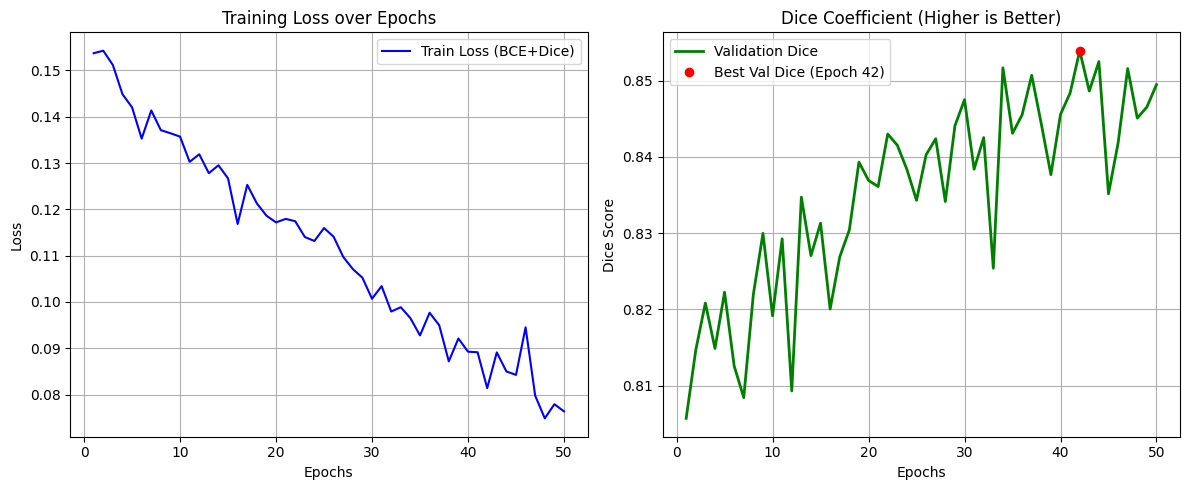

In [61]:
import matplotlib.pyplot as plt

# 1. Visualize the Loss and Dice Scores
def plot_metrics(train_losses, val_dices, train_dices=None):
    epochs = range(1, len(train_losses) + 1)

    plt.figure(figsize=(12, 5))

    # Plot 1: BCE Loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_losses, 'b-', label='Train Loss (BCE+Dice)')
    plt.title('Training Loss over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    # Plot 2: Dice Coefficient (Validation vs Train if available)
    plt.subplot(1, 2, 2)
    if train_dices:
        plt.plot(epochs, train_dices, 'b-', label='Train Dice')
    plt.plot(epochs, val_dices, 'g-', label='Validation Dice', linewidth=2)
    
    # Highlight the best epoch
    best_epoch = val_dices.index(max(val_dices)) + 1
    plt.plot(best_epoch, max(val_dices), 'ro', label=f'Best Val Dice (Epoch {best_epoch})')

    plt.title('Dice Coefficient (Higher is Better)')
    plt.xlabel('Epochs')
    plt.ylabel('Dice Score')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

# Extract the tracked metrics from the training loop variables
# (Assuming you appended the avg_loss and val_dice to lists during the loop)
# Note: You will need to slightly modify the training loop above to append these values to lists:
# e.g., epoch_train_losses.append(avg_loss), epoch_val_dices.append(val_dice)

try:
    plot_metrics(epoch_train_losses, epoch_val_dices)
except NameError:
     print("Could not plot metrics. Ensure you are appending 'avg_loss' and 'val_dice' to lists named 'epoch_train_losses' and 'epoch_val_dices' inside your training loop.")

In [62]:
# 2. Final Model Save Configuration
# The EarlyStopping class already saved the *best* model as "breast_segmentation_unet_best.pth".
# We will explicitly load those best weights and do a final save under a clear V2 name.

print("\\n--- Saving Final Model ---")
final_model_path = "breast_segmentation_unet_best.pth"

try:
    # Load the best weights saved by the early stopper
    model.load_state_dict(torch.load(best_ckpt, weights_only=True))
    
    # Save it explicitly as the V2 model
    torch.save(model.state_dict(), final_model_path)
    print(f"Successfully saved the highest-performing model as: {final_model_path}")
    print(f"You can now use '{final_model_path}' in Phase 3 for automated segmentation.")
except Exception as e:
    print(f"Error during final save: {e}")

\n--- Saving Final Model ---
Successfully saved the highest-performing model as: breast_segmentation_unet_best.pth
You can now use 'breast_segmentation_unet_best.pth' in Phase 3 for automated segmentation.


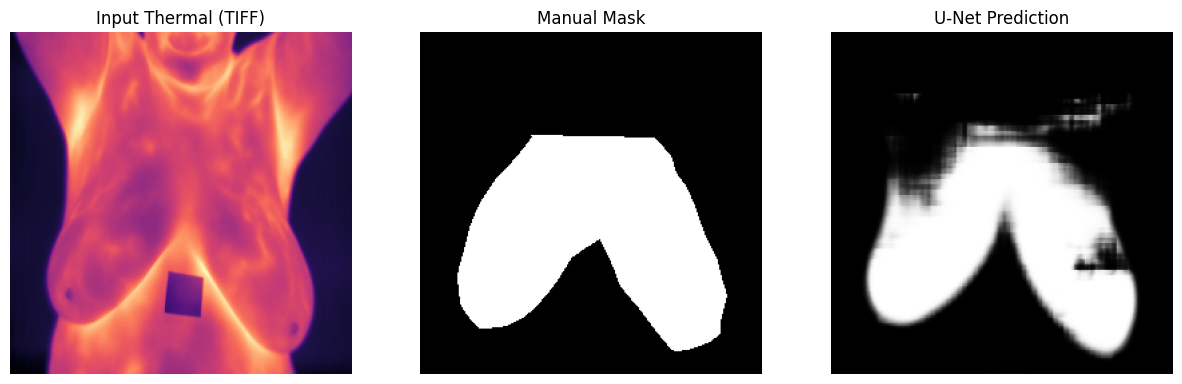

In [86]:
import matplotlib.pyplot as plt
import random

model.eval()
with torch.no_grad():
    # Grab a batch from the test loader
    imgs, masks = next(iter(test_loader))
    imgs = imgs.to(device)

    # Predict
    preds = model(imgs)

    # Plot first item in batch
    fig, axs = plt.subplots(1, 3, figsize=(15, 5))
    axs[0].imshow(imgs[0, 0].cpu(), cmap='magma')
    axs[0].set_title("Input Thermal (TIFF)")
    axs[1].imshow(masks[0, 0].cpu(), cmap='gray')
    axs[1].set_title("Manual Mask")
    axs[2].imshow(preds[0, 0].cpu(), cmap='gray')
    axs[2].set_title("U-Net Prediction")
    for ax in axs:
        ax.axis('off')
    plt.show()


---

## Inference Pipeline — Automated Segmentation & Edge Extraction

Runs the trained model over the entire TIFF dataset. For each image:

1. Normalise (Paper Eq 1)
2. U-Net forward pass → probability map
3. Binarise at threshold 0.5 (Suzuki binarisation)
4. Retain largest connected contour (removes noise)
5. Canny edge detection → boundary edge map
6. Save as `<original_name>_edge.png` preserving folder hierarchy


In [74]:
output_edges = r"C:\Users\LENOVO THINKPAD T14\Documents\PROPOSAL TA\files\Rodriguez-Guerrero Dataset\Breast Thermography\3D Reconstruction\data\Automated_Edges2"


In [76]:
def automated_segmentation(model_path, tiff_dir, output_dir):
    # Load the trained model
    # ── FIX 5: weights_only=True avoids FutureWarning in PyTorch ≥ 2.0 ─────
    model = UNet().to(device)
    model.load_state_dict(torch.load(model_path, weights_only=True))
    model.eval()

    # Find all original TIFFs
    all_tiffs = glob.glob(os.path.join(tiff_dir, "**", "*.tiff"), recursive=True)
    os.makedirs(output_dir, exist_ok=True)

    print(f"Running automated segmentation on {len(all_tiffs)} images...")

    for f_path in tqdm(all_tiffs):
        # 1. Load and Preprocess per paper Eq 1 [cite: 113, 115]
        raw     = tiff.imread(f_path)
        t_min, t_max = np.min(raw), np.max(raw)
        norm    = (raw - t_min) / (t_max - t_min + 1e-8)
        img_256 = cv2.resize(norm.astype(np.float32), (256, 256))

        # 2. U-Net Prediction [cite: 131]
        img_tensor = torch.from_numpy(img_256).unsqueeze(0).unsqueeze(0).to(device)
        with torch.no_grad():
            pred = model(img_tensor).squeeze().cpu().numpy()

        # 3. Suzuki/Binarization Filtering
        binary = (pred > 0.5).astype(np.uint8) * 255

        # 4. Retain Largest Area
        contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        clean_mask  = np.zeros_like(binary)
        # ── FIX 9: guard — skip save if no contour found ─────────────────────
        if not contours:
            print(f"Warning: no contour found for {os.path.basename(f_path)}, skipping.")
            continue
        largest = max(contours, key=cv2.contourArea)
        cv2.drawContours(clean_mask, [largest], -1, 255, thickness=cv2.FILLED)

        # 5. Canny Edge Extraction
        edges = cv2.Canny(clean_mask, 100, 200)

        # Save the finalized edge map
        rel_path  = os.path.relpath(f_path, tiff_dir)
        out_name  = os.path.splitext(rel_path)[0] + "_edge.png"
        save_path = os.path.join(output_dir, out_name)
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        cv2.imwrite(save_path, edges)


# Run the automation
model_weights = "breast_segmentation_unet_best.pth"
automated_segmentation(model_weights, TIFF_BASE, output_edges)


Running automated segmentation on 657 images...


  0%|          | 0/657 [00:00<?, ?it/s]

---

### Visualising the Generated Edge Overlays

Randomly samples `n` edge maps and overlays them (green) on the original thermal image (Magma colormap).  
`robust_read_image` bypasses Windows Unicode path issues and skips zero-byte files.


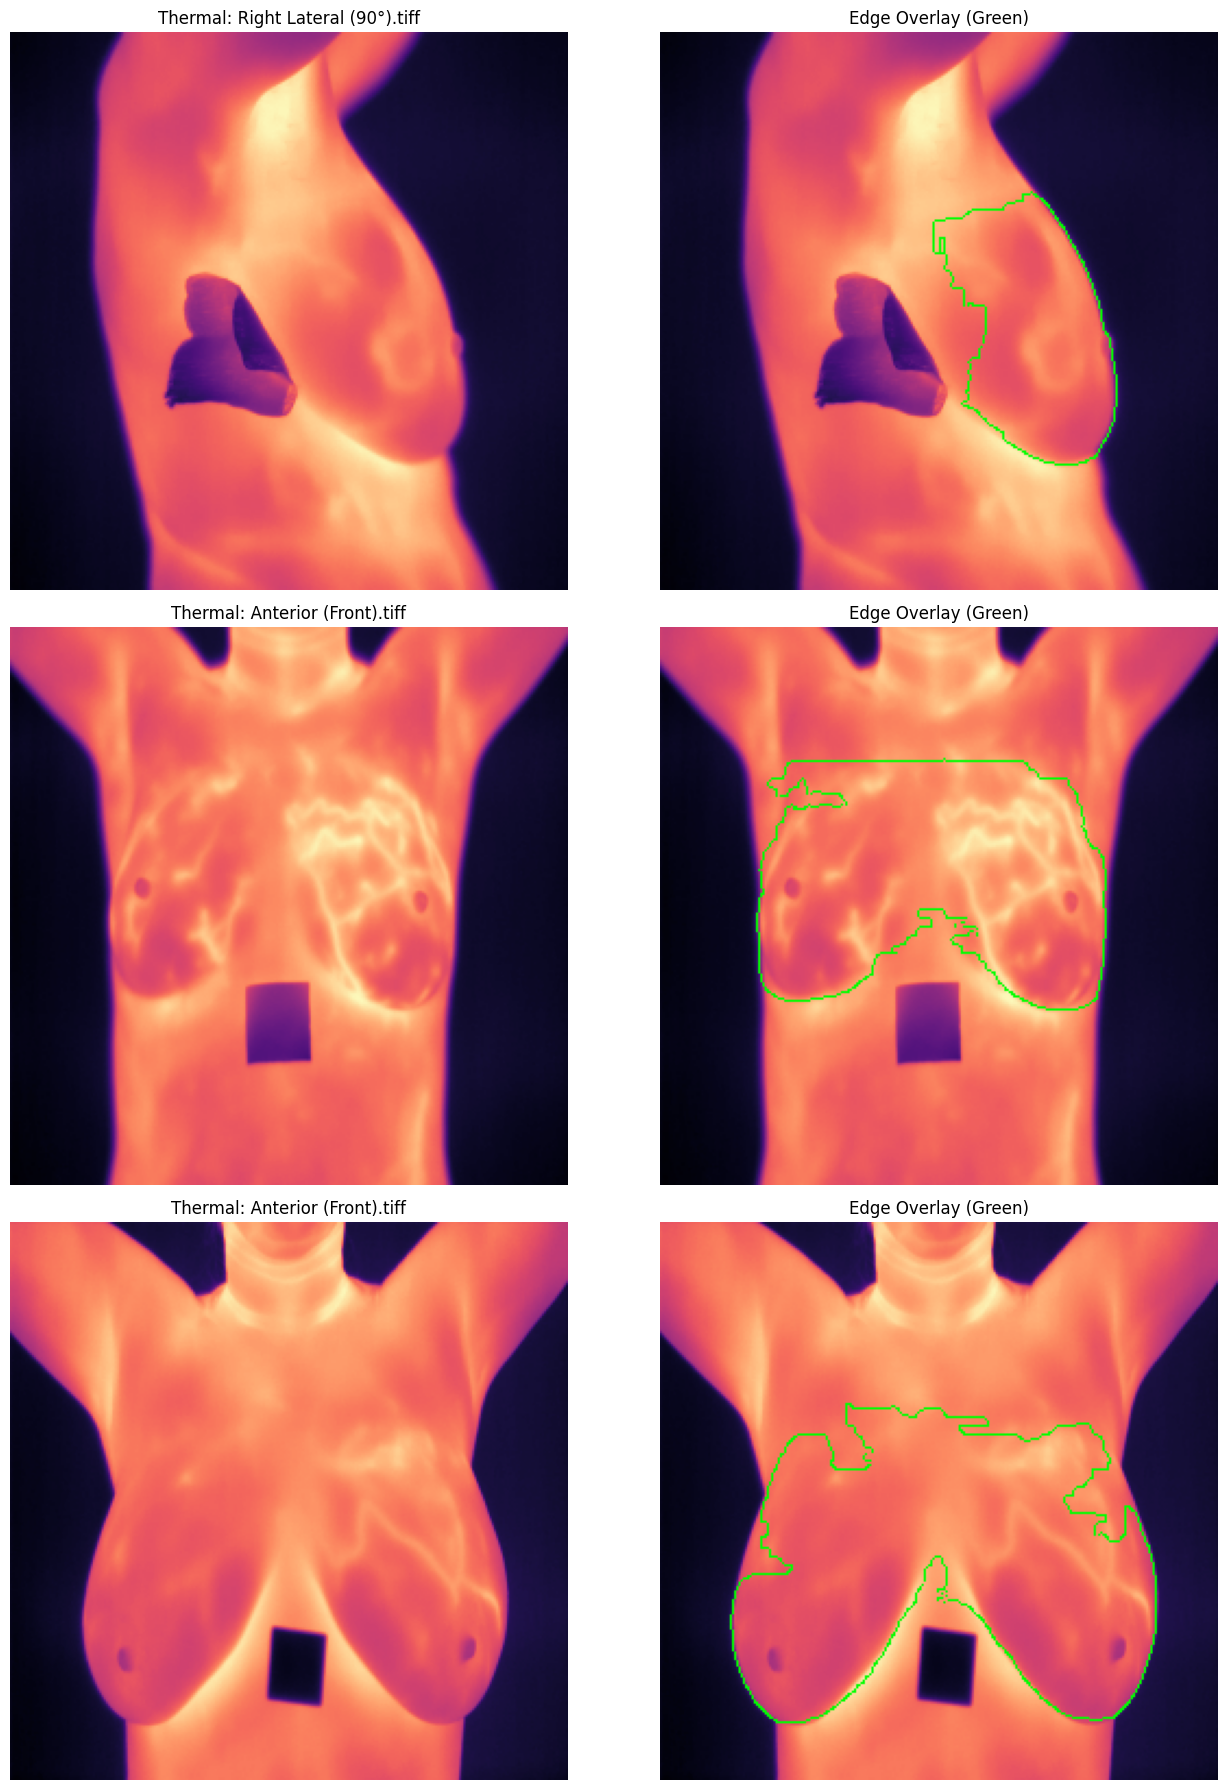

In [81]:
def robust_read_image(path, flags=cv2.IMREAD_GRAYSCALE):
    """Bypasses Windows path encoding issues and handles empty files."""
    try:
        if os.path.getsize(path) == 0:  # Check if file was stopped mid-save
            return None
        # Read file as a numpy array buffer to bypass string encoding
        img_array = np.fromfile(path, dtype=np.uint8)
        img = cv2.imdecode(img_array, flags)
        return img
    except Exception:
        return None


def ultra_robust_light_test(tiff_dir, edge_dir, num_samples=3):
    # 1. Find all generated edge maps
    edge_files = glob.glob(os.path.join(edge_dir, "**", "*_edge.png"), recursive=True)

    if not edge_files:
        print("No edge files found! Check your Automated_Edges folder.")
        return

    # 2. Pick samples and setup plotting
    samples = random.sample(edge_files, min(num_samples, len(edge_files)))
    fig, axs = plt.subplots(len(samples), 2, figsize=(14, 6 * len(samples)))
    if len(samples) == 1:
        axs = np.expand_dims(axs, axis=0)

    for i, edge_path in enumerate(samples):
        # --- ROBUST READ ---
        edge_img = robust_read_image(edge_path)

        if edge_img is None:
            print(f"Skipping corrupted or unreadable edge map: {os.path.basename(edge_path)}")
            continue

        # 3. Find corresponding TIFF using Prefix Matching
        rel_path          = os.path.relpath(edge_path, edge_dir)
        patient_subfolder = os.path.dirname(rel_path)
        edge_filename     = os.path.basename(rel_path)
        search_folder     = os.path.join(tiff_dir, patient_subfolder)
        search_prefix     = edge_filename.split('(')[0].strip()

        potential_tiffs = glob.glob(os.path.join(search_folder, "*.tiff"))
        tiff_path = next((p for p in potential_tiffs if search_prefix in os.path.basename(p)), None)

        if tiff_path is None:
            continue

        # 4. Load/Normalize TIFF and Resize to 256x256
        raw      = tiff.imread(tiff_path)
        norm     = 255 * (raw - np.min(raw)) / (np.max(raw) - np.min(raw) + 1e-8)
        norm_256 = cv2.resize(norm.astype(np.uint8), (256, 256), interpolation=cv2.INTER_AREA)
        base_display = cv2.applyColorMap(norm_256, cv2.COLORMAP_MAGMA)

        # 5. Overlay edges
        overlay = base_display.copy()
        # The 'if edge_img is not None' check prevents the TypeError
        overlay[edge_img > 0] = [0, 255, 0]

        # Plotting
        axs[i, 0].imshow(cv2.cvtColor(base_display, cv2.COLOR_BGR2RGB))
        axs[i, 0].set_title(f"Thermal: {os.path.basename(tiff_path)}")
        axs[i, 1].imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
        axs[i, 1].set_title("Edge Overlay (Green)")
        for ax in axs[i]:
            ax.axis('off')

    plt.tight_layout()
    plt.show()


# Execute the test
ultra_robust_light_test(TIFF_BASE, output_edges, num_samples=3)


---

## Phase 3 — Key Point Extraction ($P_1$, $P_2$, $P_3$)

### Step 3.1 — §3.4 Infra-Mammary Curve Isolation

The paper (§3.4) requires a **4-step pipeline** to strip the top arc and lateral silhouette edges before
anchor extraction, leaving only the infra-mammary curve. Without this, column-extremes
(`argmin/argmax col`) grab top-lateral corners rather than the true infra-mammary inflections.

| Step | Operation |
|---|---|
| 1 | Bottom-to-top scan — keep only the **lowest** edge pixel per column |
| 2 | Right-to-left scan — keep the **rightmost** edge pixel per row |
| 3 | Left-to-right scan — keep the **leftmost** edge pixel per row |
| 4 | Remove any pixel found in steps 2 or 3 from the step-1 set |


In [82]:
# ── FIX 6: §3.4 four-step infra-mammary curve isolation ─────────────────────
def extract_infra_mammary_curve(edge_map):
    """
    Isolates only the infra-mammary (bottom breast boundary) pixels from a
    full Canny silhouette edge map, as described in paper §3.4.

    Returns a binary numpy array the same shape as edge_map.
    """
    h, w = edge_map.shape
    bottom_pixels = set()
    right_pixels  = set()
    left_pixels   = set()

    # Step 1: bottom-to-top scan — lowest edge pixel per column
    for col in range(w):
        for row in range(h - 1, -1, -1):
            if edge_map[row, col] > 0:
                bottom_pixels.add((row, col))
                break

    # Step 2: right-to-left scan — rightmost edge pixel per row
    for row in range(h):
        for col in range(w - 1, -1, -1):
            if edge_map[row, col] > 0:
                right_pixels.add((row, col))
                break

    # Step 3: left-to-right scan — leftmost edge pixel per row
    for row in range(h):
        for col in range(w):
            if edge_map[row, col] > 0:
                left_pixels.add((row, col))
                break

    # Step 4: remove lateral pixels from bottom set
    lateral  = right_pixels | left_pixels
    filtered = bottom_pixels - lateral

    result = np.zeros_like(edge_map)
    for (r, c) in filtered:
        result[r, c] = 255
    return result


### Step 3.2 — Anchor Point Extraction ($P_1$, $P_2$, $P_3$)

Extracts three geometric landmarks per view. Definition differs by view angle (paper §3.5):

| View | $P_1$ | $P_2$ | $P_3$ |
|---|---|---|---|
| 0°, ±45° (frontal / oblique) | **Right** infra-mammary inflection | Center junction of curves | **Left** infra-mammary inflection |
| ±90° (side views) | Beginning of curve | **Lowest** point | End of curve |

**Fixes applied:**
- `view_angle` is now used (was accepted but ignored)
- P1 / P3 column mapping corrected (`argmax col` = rightmost = P1; `argmin col` = leftmost = P3)
- `edge_map.copy()` prevents in-place mutation of the caller's array
- Infra-mammary isolation runs first


In [83]:
# ── FIX 7: view-aware anchor extraction, P1/P3 corrected, no in-place mutation
def extract_anchors_v2(edge_map, view_angle):
    """
    Extracts P1, P2, P3 anchor points from an infra-mammary edge map.

    Parameters
    ----------
    edge_map   : np.ndarray  — grayscale Canny edge map (H x W, uint8)
    view_angle : int         — camera angle in degrees (0, 45, -45, 90, -90)

    Returns
    -------
    dict with keys 'P1', 'P2', 'P3' as (row, col) numpy arrays, or None.
    """
    # FIX: operate on a copy to avoid mutating the caller's array
    edge_map = edge_map.copy()
    h, w = edge_map.shape

    # Ignore the top 30 % of the image to remove neck/shoulder noise
    edge_map[:int(h * 0.3), :] = 0

    # FIX 6: isolate infra-mammary curve before extracting anchors (paper §3.4)
    edge_map = extract_infra_mammary_curve(edge_map)

    coords = np.column_stack(np.where(edge_map > 0))
    if len(coords) < 10:
        return None

    lower_half = coords[coords[:, 0] > (h * 0.5)]
    if len(lower_half) == 0:
        return None

    if abs(view_angle) == 90:
        # ── Side views (±90°) ────────────────────────────────────────────────
        # P1 = beginning of curve (leftmost column)
        # P2 = lowest point of curve
        # P3 = end of curve (rightmost column)
        p1 = lower_half[np.argmin(lower_half[:, 1])]   # leftmost  → beginning
        p3 = lower_half[np.argmax(lower_half[:, 1])]   # rightmost → end
        p2 = coords[np.argmax(coords[:, 0])]            # lowest pixel
    else:
        # ── Frontal / oblique (0°, ±45°) ─────────────────────────────────────
        # P1 = right inflection  → argmax column (rightmost)
        # P2 = center junction   → median index along the sorted curve
        # P3 = left inflection   → argmin column (leftmost)
        # FIX: argmax col = rightmost = P1 (was swapped in original code)
        p1 = lower_half[np.argmax(lower_half[:, 1])]   # rightmost → P1
        p3 = lower_half[np.argmin(lower_half[:, 1])]   # leftmost  → P3
        p2 = lower_half[len(lower_half) // 2]           # center of curve → P2

    return {"P1": p1, "P2": p2, "P3": p3}


### Step 3.3 — Test Anchor Extraction on a Patient

Visualises P1 (blue), P2 (red), P3 (green) overlaid on edge maps for the first three views of a patient.

**Fixes applied:**
- Calls `extract_anchors_v2` with a numpy array (was calling undefined `extract_anchors` with a file path)
- Angle detection extended to cover negative angles (`-90`, `-45`)


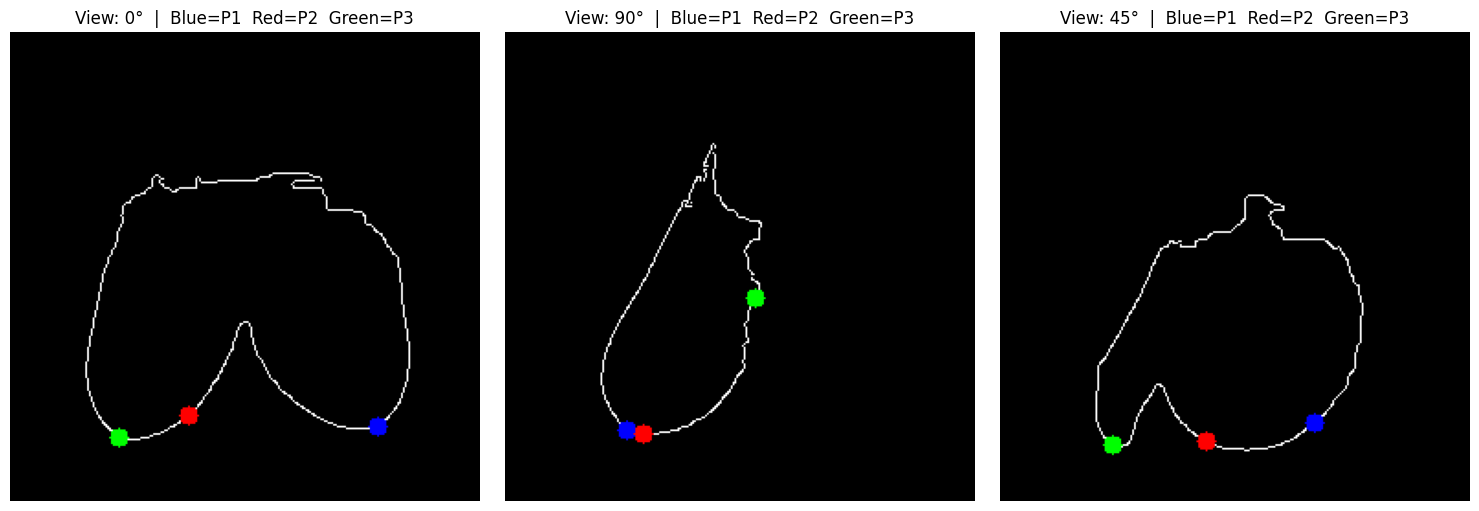

In [85]:
# ── FIX 8: correct function name + correct argument type ─────────────────────
def test_coordinate_extraction(edge_dir, patient_id="Patient_106"):
    """Visualises P1/P2/P3 anchors for the first 3 view edge maps of a patient."""
    patient_path = os.path.join(edge_dir, patient_id)
    edge_files   = glob.glob(os.path.join(patient_path, "**", "*.png"), recursive=True)

    if not edge_files:
        print(f"No edges found for {patient_id}. Did you generate them?")
        return

    plt.figure(figsize=(15, 5))
    for i, f_path in enumerate(edge_files[:3]):  # Test first 3 views
        # Determine angle from filename (covers ±90 and ±45)
        angle = 0
        fname = os.path.basename(f_path)
        if "-90" in fname:   angle = -90
        elif "90" in fname:  angle =  90
        elif "-45" in fname: angle = -45
        elif "45" in fname:  angle =  45

        # FIX: load numpy array first, then pass to extract_anchors_v2
        edge_map = cv2.imdecode(np.fromfile(f_path, dtype=np.uint8), cv2.IMREAD_GRAYSCALE)
        if edge_map is None:
            continue
        anchors = extract_anchors_v2(edge_map, angle)  # FIX: correct name + correct arg
        if not anchors:
            continue

        # Load colour image for display
        img = cv2.imdecode(np.fromfile(f_path, dtype=np.uint8), cv2.IMREAD_COLOR)

        # Draw the points: P1(Blue), P2(Red), P3(Green)
        cv2.circle(img, (anchors["P1"][1], anchors["P1"][0]), 5, (255, 0,   0), -1)
        cv2.circle(img, (anchors["P2"][1], anchors["P2"][0]), 5, (0,   0, 255), -1)
        cv2.circle(img, (anchors["P3"][1], anchors["P3"][0]), 5, (0, 255,   0), -1)

        plt.subplot(1, 3, i + 1)
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        plt.title(f"View: {angle}°  |  Blue=P1  Red=P2  Green=P3")
        plt.axis('off')

    plt.tight_layout()
    plt.show()


# Run the test on a patient you already generated
test_coordinate_extraction(output_edges, patient_id="Patient_13")
